In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/Predun/OneDrive/Desktop/Assignment 5/Dataset/ai_project_synthetic_datasets/part_3_nlp_sequence_modeling/customer_support_text_classification.csv")


In [3]:
# Basic info
print("--- Dataset Shape ---")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

--- Dataset Shape ---
Rows    : 1500
Columns : 6


In [4]:
# Basic info
print("--- Dataset Shape ---")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

--- Dataset Shape ---
Rows    : 1500
Columns : 6


In [5]:
# Data types
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
ticket_id           object
channel             object
customer_message    object
sentiment_label     object
word_count           int64
urgent_flag          int64
dtype: object


In [6]:
# Missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


--- Missing Values ---
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64

Total missing values: 0


In [7]:
# Target classes
print("\n--- Target Classes ---")
print(df['sentiment_label'].value_counts())


--- Target Classes ---
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [8]:
# Class distribution percentage
print("\n--- Class Distribution (%) ---")
total = len(df)
for label in df['sentiment_label'].value_counts().index:
    count = df['sentiment_label'].value_counts()[label]
    pct   = count / total * 100
    print(f"{label:<10} : {count} records ({pct:.1f}%)")


--- Class Distribution (%) ---
neutral    : 524 records (34.9%)
negative   : 497 records (33.1%)
positive   : 479 records (31.9%)


In [9]:
# Sample text records
print("\n--- Sample Text Records ---")
for i in range(5):
    msg   = df['customer_message'].iloc[i]
    label = df['sentiment_label'].iloc[i]
    chan  = df['channel'].iloc[i]
    print(f"\n{i+1}. Channel  : {chan}")
    print(f"   Sentiment: {label}")
    print(f"   Message  : {msg}")


--- Sample Text Records ---

1. Channel  : chat
   Sentiment: neutral
   Message  : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

2. Channel  : phone
   Sentiment: neutral
   Message  : I need information about the payment process.

3. Channel  : email
   Sentiment: positive
   Message  : The refund process was fast and convenient. I appreciate the quick response.

4. Channel  : social
   Sentiment: negative
   Message  : My refund is still pending and this experience is frustrating. My ticket number is 33927.

5. Channel  : chat
   Sentiment: neutral
   Message  : Please tell me how to update my account details.


In [10]:
# Average text length
print("\n--- Text Length Statistics ---")
print(f"Average word count : {df['word_count'].mean():.2f}")
print(f"Min word count     : {df['word_count'].min()}")
print(f"Max word count     : {df['word_count'].max()}")
print(f"Median word count  : {df['word_count'].median()}")


--- Text Length Statistics ---
Average word count : 12.72
Min word count     : 7
Max word count     : 26
Median word count  : 12.0


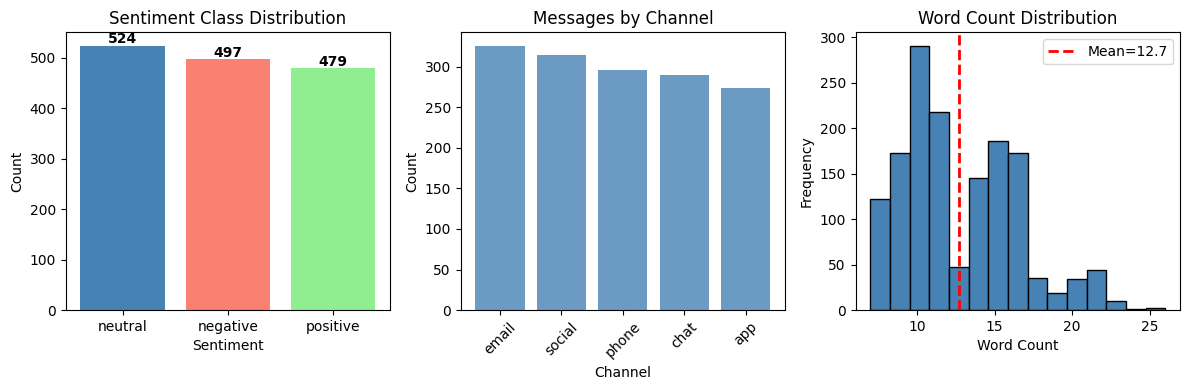

In [12]:
# Plot class distribution
plt.figure(figsize=(12, 4))

# Plot 1 - Sentiment distribution
plt.subplot(1, 3, 1)
counts = df['sentiment_label'].value_counts()
colors = ['steelblue', 'salmon', 'lightgreen']
plt.bar(counts.index, counts.values, color=colors)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
for i, (label, count) in enumerate(counts.items()):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')

# Plot 2 - Channel distribution
plt.subplot(1, 3, 2)
chan_counts = df['channel'].value_counts()
plt.bar(chan_counts.index, chan_counts.values, color='steelblue', alpha=0.8)
plt.title("Messages by Channel")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Plot 3 - Word count distribution
plt.subplot(1, 3, 3)
plt.hist(df['word_count'].tolist(), bins=15, color='steelblue', edgecolor='black')
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.axvline(df['word_count'].mean(), color='red',
            linestyle='dashed', linewidth=2, label=f"Mean={df['word_count'].mean():.1f}")
plt.legend()

plt.tight_layout()
plt.savefig("plot1_dataset_overview.png")
plt.show()

## Task 2: Text Preprocessing

In [14]:
import re
import string

# Step 1 - Lowercase all text
print("--- Step 1: Lowercasing ---")
df['clean_message'] = df['customer_message'].str.lower() #Lowercasing makes sure same words are treated as same word

print("Before:", df['customer_message'].iloc[0])
print("After :", df['clean_message'].iloc[0])

--- Step 1: Lowercasing ---
Before: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
After : i need information about the payment process. my ticket number is 78732. please respond as soon as possible.


In [15]:
# Step 2 - Remove special characters, numbers, punctuation
print("\n--- Step 2: Removing Special Characters ---")

def clean_text(text):

    # Remove ticket numbers like "78732"
    text = re.sub(r'\d+', '', text) # ticket number are unique which is not helpful for the model 

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation)) # punctuations are also irrelevant which might confuwe the model

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)

    # Strip leading and trailing spaces
    text = text.strip() # Keeping them adds noise and increases vocabulary size unnecessarily

    return text

df['clean_message'] = df['clean_message'].apply(clean_text)

print("Before:", df['customer_message'].iloc[0])
print("After :", df['clean_message'].iloc[0])


--- Step 2: Removing Special Characters ---
Before: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
After : i need information about the payment process my ticket number is please respond as soon as possible


In [16]:
# Step 3 - Tokenization - Computers cannot understand sentences. They need individual words (tokens) as separate units, Tokenization splits "i am happy" → ["i", "am", "happy"]
# Now we can count words, build vocabulary etc
print("\n--- Step 3: Tokenization ---") 

def tokenize(text):
    # Split by spaces to get individual words
    tokens = text.split()
    return tokens

df['tokens'] = df['clean_message'].apply(tokenize)

print("Sample tokens:")
for i in range(3):
    print(f"\n{i+1}. Original : {df['customer_message'].iloc[i]}")
    print(f"   Tokens   : {df['tokens'].iloc[i]}")


--- Step 3: Tokenization ---
Sample tokens:

1. Original : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
   Tokens   : ['i', 'need', 'information', 'about', 'the', 'payment', 'process', 'my', 'ticket', 'number', 'is', 'please', 'respond', 'as', 'soon', 'as', 'possible']

2. Original : I need information about the payment process.
   Tokens   : ['i', 'need', 'information', 'about', 'the', 'payment', 'process']

3. Original : The refund process was fast and convenient. I appreciate the quick response.
   Tokens   : ['the', 'refund', 'process', 'was', 'fast', 'and', 'convenient', 'i', 'appreciate', 'the', 'quick', 'response']


In [18]:
# Step 4 - Remove stopwords - Stopwords are very common words . They appear in ALL sentiments equally.So they do not help the model distinguish positive from negative
#Removing them reduces noise and focuses on meaningful words

stopwords = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves',
             'you', 'your', 'yours', 'he', 'him', 'his', 'she', 'her',
             'it', 'its', 'they', 'them', 'their', 'what', 'which',
             'this', 'that', 'these', 'those', 'am', 'is', 'are', 'was',
             'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do',
             'does', 'did', 'will', 'would', 'could', 'should', 'may',
             'might', 'must', 'can', 'a', 'an', 'the', 'and', 'but',
             'or', 'nor', 'for', 'so', 'yet', 'both', 'either', 'neither',
             'not', 'only', 'own', 'same', 'than', 'too', 'very', 'just',
             'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for',
             'with', 'about', 'against', 'between', 'into', 'through',
             'to', 'from', 'in', 'out', 'on', 'off', 'over', 'under',
             'again', 'then', 'once', 'here', 'there', 'when', 'where',
             'who', 'how', 'all', 'each', 'any', 'such', 'no', 'up',
             'if', 'after', 'before', 'during', 'above', 'below']

def remove_stopwords(tokens):
    filtered = []
    for token in tokens:
        if token not in stopwords:
            filtered.append(token)
    return filtered

df['tokens_clean'] = df['tokens'].apply(remove_stopwords)

print("Before stopword removal:")
print(df['tokens'].iloc[2])
print("\nAfter stopword removal:")
print(df['tokens_clean'].iloc[2])

Before stopword removal:
['the', 'refund', 'process', 'was', 'fast', 'and', 'convenient', 'i', 'appreciate', 'the', 'quick', 'response']

After stopword removal:
['refund', 'process', 'fast', 'convenient', 'appreciate', 'quick', 'response']


In [19]:
# Step 5 - Rejoin cleaned tokens into string for vectorization
df['final_text'] = df['tokens_clean'].apply(lambda tokens: ' '.join(tokens))

print("\n--- Final Cleaned Text Sample ---")
for i in range(5):
    print(f"\n{i+1}. Original : {df['customer_message'].iloc[i]}")
    print(f"   Cleaned  : {df['final_text'].iloc[i]}")


--- Final Cleaned Text Sample ---

1. Original : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
   Cleaned  : need information payment process ticket number please respond soon possible

2. Original : I need information about the payment process.
   Cleaned  : need information payment process

3. Original : The refund process was fast and convenient. I appreciate the quick response.
   Cleaned  : refund process fast convenient appreciate quick response

4. Original : My refund is still pending and this experience is frustrating. My ticket number is 33927.
   Cleaned  : refund still pending experience frustrating ticket number

5. Original : Please tell me how to update my account details.
   Cleaned  : please tell update account details


In [21]:
# Encode target labels to numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['sentiment_label'])

print("\n--- Label Encoding ---")
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"{label:<10} → {code}")


--- Label Encoding ---
negative   → 0
neutral    → 1
positive   → 2


## Task 3: Text Vectorization

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
# Bag of Words 

print("--- Method 1: Bag of Words ---")

bow_vectorizer = CountVectorizer(max_features=1000)
X_bow          = bow_vectorizer.fit_transform(df['final_text'])

print(f"Vocabulary size  : {len(bow_vectorizer.vocabulary_)}")
print(f"Matrix shape     : {X_bow.shape}")
print(f"One row = vector of {X_bow.shape[1]} numbers")
print(f"\nSample vocabulary (first 20 words):")
vocab_list = list(bow_vectorizer.vocabulary_.keys())[:20]
print(vocab_list)

# Show BoW vector for first message
sample_bow = X_bow[0].toarray()[0]
nonzero_idx = np.where(sample_bow > 0)[0]

print(f"\nBoW vector for first message:")
print(f"Message: {df['final_text'].iloc[0]}")
print("Non-zero features:")
for idx in nonzero_idx:
    word  = vocab_list[idx] if idx < len(vocab_list) else "?"
    count = sample_bow[idx]
    print(f"  word index {idx} : count = {int(count)}")

--- Method 1: Bag of Words ---
Vocabulary size  : 146
Matrix shape     : (1500, 146)
One row = vector of 146 numbers

Sample vocabulary (first 20 words):
['need', 'information', 'payment', 'process', 'ticket', 'number', 'please', 'respond', 'soon', 'possible', 'refund', 'fast', 'convenient', 'appreciate', 'quick', 'response', 'still', 'pending', 'experience', 'frustrating']

BoW vector for first message:
Message: need information payment process ticket number please respond soon possible
Non-zero features:
  word index 46 : count = 1
  word index 64 : count = 1
  word index 68 : count = 1
  word index 72 : count = 1
  word index 77 : count = 1
  word index 80 : count = 1
  word index 82 : count = 1
  word index 100 : count = 1
  word index 111 : count = 1
  word index 123 : count = 1


## Task 4: Baseline Model

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Split data
X = df['final_text']
y = df['label_encoded']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"Training samples : {len(X_train_text)}")
print(f"Testing samples  : {len(X_test_text)}")

Training samples : 1200
Testing samples  : 300


In [29]:
print("\n--- Baseline Model 1: Naive Bayes + BoW ---")

# Vectorize
bow_vec    = CountVectorizer(max_features=1000)
X_train_bow = bow_vec.fit_transform(X_train_text)
X_test_bow  = bow_vec.transform(X_test_text)

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_bow)

# Evaluate
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"Accuracy: {nb_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb,
      target_names=le.classes_))


--- Baseline Model 1: Naive Bayes + BoW ---
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [31]:
print("\n--- Baseline Model 2: Logistic Regression + TF-IDF ---")

# Vectorize
tfidf_vec    = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
X_test_tfidf  = tfidf_vec.transform(X_test_text)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluate
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy: {lr_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=le.classes_))


--- Baseline Model 2: Logistic Regression + TF-IDF ---
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



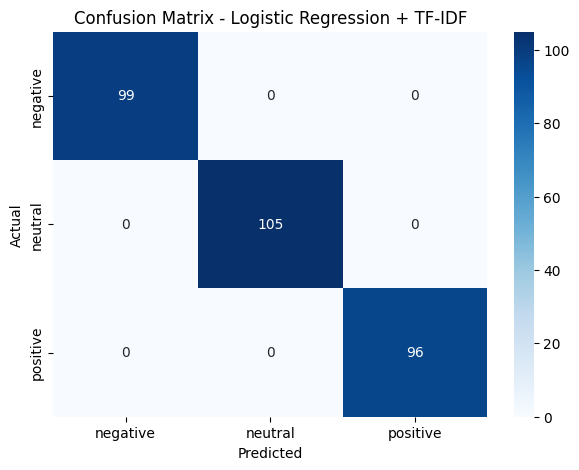

In [37]:
# Confusion matrix for best baseline
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot       = True,
            fmt         = 'd',
            cmap        = 'Blues',
            xticklabels = le.classes_,
            yticklabels = le.classes_)
plt.title("Confusion Matrix - Logistic Regression + TF-IDF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("plot2_baseline_confusion_matrix.png")
plt.show()

In [38]:
# Show sample predictions from baseline model
print("\n--- Sample Predictions (Baseline Model) ---")

test_messages = X_test_text.values
test_actual   = y_test.values
test_vectors  = X_test_tfidf

for i in range(10):
    actual    = le.classes_[test_actual[i]]
    predicted = le.classes_[y_pred_lr[i]]

    if actual == predicted:
        status = "Correct"
    else:
        status = "Wrong"

    print(f"\n{i+1}. Message  : {test_messages[i][:60]}...")
    print(f"   Actual   : {actual}")
    print(f"   Predicted: {predicted}  {status}")


--- Sample Predictions (Baseline Model) ---

1. Message  : like new payment easy use ticket number...
   Actual   : positive
   Predicted: positive  Correct

2. Message  : great service clear communication support team...
   Actual   : positive
   Predicted: positive  Correct

3. Message  : refund still pending experience frustrating...
   Actual   : negative
   Predicted: negative  Correct

4. Message  : app crashes whenever try use analytics...
   Actual   : negative
   Predicted: negative  Correct

5. Message  : response team helpful professional...
   Actual   : positive
   Predicted: positive  Correct

6. Message  : someone explain difference plans...
   Actual   : neutral
   Predicted: neutral  Correct

7. Message  : like new video call easy use...
   Actual   : positive
   Predicted: positive  Correct

8. Message  : like new report download easy use...
   Actual   : positive
   Predicted: positive  Correct

9. Message  : someone explain difference plans...
   Actual   : neutral

## Task 5: Sequence Model or Conceptual Architecture

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [42]:
print("\n--- Tokenizer Sequences (for Deep Learning) ---")

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Build vocabulary from training text
max_vocab  = 2000
max_length = 30

tokenizer = Tokenizer(num_words=max_vocab, oov_token='<OOV>')
tokenizer.fit_on_texts(df['final_text'])

print(f"Vocabulary size  : {len(tokenizer.word_index)}")
print(f"Using top        : {max_vocab} words")

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df['final_text'])

print(f"\nSample sequence conversion:")
print(f"Text    : {df['final_text'].iloc[0]}")
print(f"Sequence: {sequences[0]}")

# Pad sequences to same length
padded_sequences = pad_sequences(sequences, maxlen=max_length,
                                  padding='post', truncating='post')

print(f"\nAfter padding (maxlen={max_length}):")
print(f"Shape   : {padded_sequences.shape}")
print(f"Sample  : {padded_sequences[0]}")


--- Tokenizer Sequences (for Deep Learning) ---
Vocabulary size  : 147
Using top        : 2000 words

Sample sequence conversion:
Text    : need information payment process ticket number please respond soon possible
Sequence: [15, 105, 64, 19, 2, 3, 4, 5, 6, 7]

After padding (maxlen=30):
Shape   : (1500, 30)
Sample  : [ 15 105  64  19   2   3   4   5   6   7   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]


In [43]:
# Prepare data for LSTM
# Split padded sequences

X_lstm      = padded_sequences
y_lstm      = df['label_encoded'].values

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_lstm, y_lstm,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_lstm
)

print(f"Training sequences shape : {X_train_seq.shape}")
print(f"Testing sequences shape  : {X_test_seq.shape}")

Training sequences shape : (1200, 30)
Testing sequences shape  : (300, 30)


In [44]:
# Build LSTM model
tf.random.set_seed(42)
np.random.seed(42)

lstm_model = keras.Sequential()

# Embedding layer
lstm_model.add(layers.Embedding(
    input_dim    = max_vocab,
    output_dim   = 64,
    input_length = max_length
))

# LSTM layer
lstm_model.add(layers.LSTM(
    units           = 64,
    dropout         = 0.3,
    recurrent_dropout = 0.3
))

# Dense hidden layer
lstm_model.add(layers.Dense(32, activation='relu'))

# Dropout
lstm_model.add(layers.Dropout(0.3))

# Output layer - 3 classes
lstm_model.add(layers.Dense(3, activation='softmax'))

# Compile
lstm_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

lstm_model.summary()

C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
layers.Embedding(input_dim=max_vocab, output_dim=64, input_length=max_length)

<Embedding name=embedding_1, built=False>

In [48]:
layers.LSTM(units=64, dropout=0.3, recurrent_dropout=0.3) 

#units=64 means 64 memory cells, dropout=0.3 drops 30% of input connections to prevent overfitting, recurrent_dropout=0.3 drops 30% of recurrent connections

<LSTM name=lstm_3, built=False>

In [49]:
layers.Dense(3, activation='softmax') 

# 3 neurons — one per sentiment class, Softmax converts to probabilities summing to 1, [0.1, 0.2, 0.7] means 70% confident it is negative

<Dense name=dense_2, built=False>

In [50]:
# Train LSTM
print("Training LSTM model...")

lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs           = 20,
    batch_size       = 32,
    validation_split = 0.2,
    verbose          = 1
)

print("LSTM training complete!")

Training LSTM model...
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.3469 - loss: 1.1011 - val_accuracy: 0.3042 - val_loss: 1.1011
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3094 - loss: 1.0998 - val_accuracy: 0.3375 - val_loss: 1.0985
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3448 - loss: 1.0985 - val_accuracy: 0.3375 - val_loss: 1.0971
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5510 - loss: 0.9412 - val_accuracy: 0.6958 - val_loss: 0.5838
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6458 - loss: 0.5311 - val_accuracy: 0.6417 - val_loss: 0.4661
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6823 - loss: 0.4589 - val_accuracy: 0.6417 - val_loss: 0.4640
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6656 - loss: 0.4622 - val_accuracy: 0.6417 - val_loss: 0.4625
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6802 - loss: 0.4557 - v

In [51]:
# Evaluate LSTM
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)

print(f"\n--- LSTM Evaluation ---")
print(f"Test Accuracy : {lstm_acc * 100:.2f}%")
print(f"Test Loss     : {lstm_loss:.4f}")

# Get predictions
y_pred_lstm_prob = lstm_model.predict(X_test_seq)
y_pred_lstm      = np.argmax(y_pred_lstm_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_lstm,
      target_names=le.classes_))


--- LSTM Evaluation ---
Test Accuracy : 68.00%
Test Loss     : 0.4551
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step 

Classification Report:
              precision    recall  f1-score   support

    negative       0.51      1.00      0.67        99
     neutral       1.00      1.00      1.00       105
    positive       0.00      0.00      0.00        96

    accuracy                           0.68       300
   macro avg       0.50      0.67      0.56       300
weighted avg       0.52      0.68      0.57       300



C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

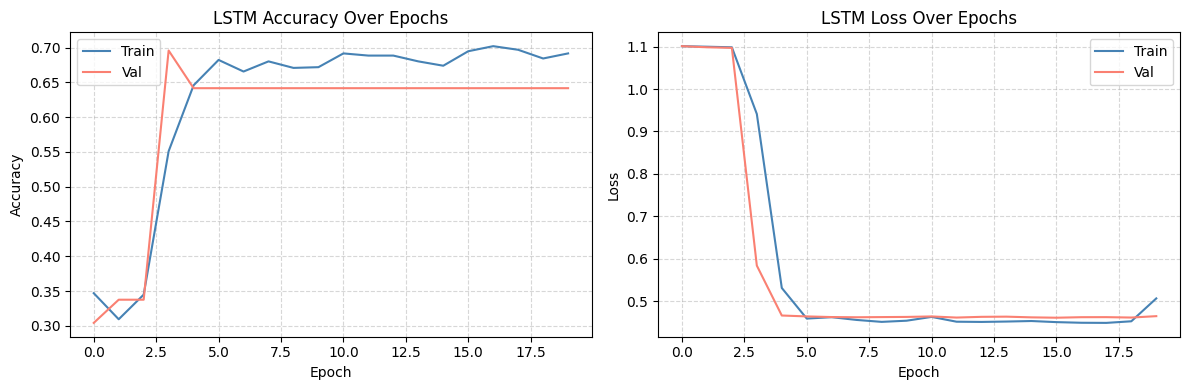

In [52]:
# Plot LSTM training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'],     label='Train', color='steelblue')
plt.plot(lstm_history.history['val_accuracy'], label='Val',   color='salmon')
plt.title("LSTM Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'],     label='Train', color='steelblue')
plt.plot(lstm_history.history['val_loss'], label='Val',   color='salmon')
plt.title("LSTM Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("plot3_lstm_training.png")
plt.show()

In [53]:
# Compare all models
print("\n--- Final Model Comparison ---")
print(f"Naive Bayes + BoW        : {nb_accuracy * 100:.2f}%")
print(f"Logistic Reg + TF-IDF   : {lr_accuracy * 100:.2f}%")
print(f"LSTM + Embeddings        : {lstm_acc * 100:.2f}%")


--- Final Model Comparison ---
Naive Bayes + BoW        : 100.00%
Logistic Reg + TF-IDF   : 100.00%
LSTM + Embeddings        : 68.00%


## Task 6: Attention and Transformer Reflection

=== TASK 6: ATTENTION AND TRANSFORMER REFLECTION ===

--- 1. Why RNNs Struggle with Long-Term Dependencies ---

RNN processes text word by word in a sequence:
word1 → word2 → word3 → ... → word50 → output

Problem: The HIDDEN STATE is the only memory
It gets UPDATED at every step
By the time we reach word 50 the information from word 1
has been diluted through 49 updates

Real example:
"The food at this restaurant which opened last year
 after the renovation was absolutely terrible"

By the time RNN reads "terrible"
it has almost FORGOTTEN "food" from the beginning!
So it cannot properly connect "terrible" to "food"

This is the VANISHING GRADIENT problem:
- Gradients get smaller and smaller going back through time
- Early words have almost zero impact on the final output
- Model cannot learn long-range relationships

--- 2. How LSTMs Help with Memory ---

LSTM solves this with THREE SPECIAL GATES:

FORGET GATE:
Decides what to THROW AWAY from memory
"We talked about food then the restaurant name then location"
The location is irrelevant so forget it
Keep: food was terrible

INPUT GATE:
Decides what NEW information to ADD to memory
When reading "terrible" the input gate says
"This is important sentiment info - store it!"
Update memory with: negative sentiment detected

OUTPUT GATE:
Decides what to OUTPUT from current memory
Based on what we remembered and what we just read
Output a summary vector for the next step

Result:
LSTM can remember "food" from word 1 when it reads "terrible" at word 15
The gates PROTECT important information from being overwritten
LSTMs can handle sequences of 50-100 words much better than basic RNN

Still limited because:
- Processing is still SEQUENTIAL (word by word)
- Cannot be parallelized easily
- Very long sequences (500+ words) still cause issues

--- 3. What Attention Solves in Sequence-to-Sequence Tasks ---

Attention was introduced for MACHINE TRANSLATION:
"The cat sat on the mat" → French translation

Old approach (RNN encoder-decoder):
Encode entire English sentence into ONE fixed vector
Decode that vector into French word by word
Problem: one vector cannot capture ALL information for long sentences!

ATTENTION SOLUTION:
Instead of one fixed vector use ALL encoder hidden states
When generating each French word:
- Look at ALL English words at once
- Assign WEIGHTS showing which English words are most relevant
- Focus on (pay attention to) the most relevant words

Example:
Translating "sat" in French
Attention weights: cat=0.1, sat=0.8, on=0.05, the=0.05
Model focuses mostly on "sat" (the word being translated)

Benefits:
1. NO information bottleneck - access to all positions directly
2. Can handle longer sequences
3. Interpretable - we can visualize which words the model attended to
4. Parallelizable - all attention scores computed simultaneously

For sentiment:
"The service was fantastic but the food was awful"
When predicting sentiment of "food" part:
Attention focuses on "food" and "awful" not "fantastic"

--- 4. Why Transformers are Important in Modern NLP and Generative AI ---

TRANSFORMER ARCHITECTURE (2017 - "Attention is All You Need"):
Completely REPLACED recurrent layers with SELF-ATTENTION

Key innovations:

1. SELF-ATTENTION:
   Every word attends to every other word SIMULTANEOUSLY
   No sequential processing needed!
   "bank" in "river bank" vs "bank account"
   Self-attention uses surrounding words to understand which meaning

2. PARALLELIZATION:
   RNN: must process word 1 then word 2 then word 3... (sequential)
   Transformer: processes ALL words at the SAME TIME (parallel)
   Result: 10-100x faster training on modern GPUs!

3. POSITIONAL ENCODING:
   Since we process all words at once we need to tell the model
   word ORDER information
   Add special position vectors to each word embedding

4. MULTI-HEAD ATTENTION:
   Run attention multiple times in parallel (e.g. 8 heads)
   Each head learns different relationships:
   Head 1: focus on nearby words (local context)
   Head 2: focus on subject-verb relationships
   Head 3: focus on sentiment-carrying words
   Combines all heads for richer understanding

WHY TRANSFORMERS DOMINATE MODERN NLP:

BERT (2018):
- Bidirectional transformer encoder
- Pre-trained on 3 billion words
- Fine-tuned for specific tasks
- Revolutionized: text classification, NER, QA

GPT series (2018-2024):
- Transformer decoder for TEXT GENERATION
- GPT-4 powers ChatGPT
- Trained on most of the internet
- Can write code, essays, answer questions

Why Generative AI runs on Transformers:
1. Scale: can be trained on MASSIVE datasets (trillions of tokens)
2. Emergent abilities: at scale models learn new abilities never explicitly taught
3. Context window: modern transformers handle 128K+ tokens at once
4. Transfer learning: one large model fine-tuned for many tasks

Comparison summary:
RNN:         Sequential, forgets long context, small scale
LSTM:        Better memory, still sequential, moderate scale
Attention:   Direct connections, but still needs RNN
Transformer: Fully parallel, perfect memory, unlimited scale
             → Powers ALL modern AI: ChatGPT, Gemini, Claude, DALL-E
""")